## Recurrent Neural Network Implementation

In [1]:
# importing the libraries
import numpy as np

In [13]:
# model
class RNNFromScratch:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.hidden_size = hidden_size
        self.lr = lr
        
        # weight matrices
        self.W_x = np.random.randn(hidden_size, input_size) * 0.01
        self.W_h = np.random.randn(hidden_size, hidden_size) * 0.01
        self.b_h = np.zeros(hidden_size)
        
        self.W_y = np.random.randn(output_size, hidden_size) * 0.01
        self.b_y = np.zeros(output_size)
    
    def tanh(self, z):
        return np.tanh(z)

    def tanh_derivative(self, z):
        return 1 - np.tanh(z) ** 2
    
    def softmax(self, z):
        e_z = np.exp(z - np.max(z))
        return e_z / e_z.sum()
    
    def forward(self, inputs, h_prev):
        self.inputs = inputs
        self.hidden_states = [h_prev]
        self.pre_activations = []
        self.outputs = []

        for x in inputs:
            z = self.W_x @ x + self.W_h @ self.hidden_states[-1] + self.b_h
            h = self.tanh(z)
            y = self.softmax(self.W_y @ h + self.b_y)
            self.pre_activations.append(z)
            self.hidden_states.append(h)
            self.outputs.append(y)

        return self.outputs, self.hidden_states

    def backward(self, inputs, targets):
        # initializing gradients
        dW_x = np.zeros_like(self.W_x)
        dW_h = np.zeros_like(self.W_h)
        db_h = np.zeros_like(self.b_h)
        dW_y = np.zeros_like(self.W_y)
        db_y = np.zeros_like(self.b_y)

        dh_next = np.zeros(self.hidden_size)
        total_loss = 0

        # backprop through time (backwards from last timestep)
        for t in reversed(range(len(inputs))):
            y_pred = self.outputs[t]
            target = targets[t]

            # output layer gradient
            dy = y_pred.copy()
            dy[target] -= 1

            # output weight gradients
            dW_y += np.outer(dy, self.hidden_states[t+1])
            db_y += dy

            # gradient flowing back into hidden state
            dh = self.W_y.T @ dy + dh_next

            # through tanh
            dz = dh * self.tanh_derivative(self.pre_activations[t])

            # weight gradients
            dW_x += np.outer(dz, inputs[t])
            dW_h += np.outer(dz, self.hidden_states[t])
            db_h += dz

            # gradient for previous timestep
            dh_next = self.W_h.T @ dz

            # loss
            total_loss += -np.log(y_pred[target] + 1e-8)

        # gradient clipping (this prevents exploding gradients)
        for grad in [dW_x, dW_h, db_h, dW_y, db_y]:
            np.clip(grad, -5, 5, out=grad)

        # updating the weights
        self.W_x -= self.lr * dW_x
        self.W_h -= self.lr * dW_h
        self.b_h -= self.lr * db_h
        self.W_y -= self.lr * dW_y
        self.b_y -= self.lr * db_y

        return total_loss / len(inputs)

    def sample(self, start_idx, vocab_size, n_chars=50):
        h = np.zeros(self.hidden_size)
        x = np.zeros(vocab_size)
        x[start_idx] = 1
        result = [start_idx]

        for _ in range(n_chars):
            outputs, hidden_states = self.forward([x], h)
            h = hidden_states[-1]
            # sample from probability distribution
            next_idx = np.random.choice(vocab_size, p=outputs[0])
            result.append(next_idx)
            x = np.zeros(vocab_size)
            x[next_idx] = 1

        return result

Vocabulary: [' ', 'a', 'c', 'e', 'h', 'm', 'n', 'o', 'r', 's', 't']
Vocab size: 11
Epoch 0: loss=2.3584
Sample: tsctc  mohnoamrescrreentstm tscetcs oomco
Epoch 100: loss=0.0646
Sample: t on the mat sat sat sat sat sat mat sat 
Epoch 200: loss=0.0504
Sample: the cat sat sat sat sat sat sat sat sat s
Epoch 300: loss=0.0474
Sample: t on the mat sat rat sat sathsaras rat sa
Epoch 400: loss=0.0458
Sample: t on the mat sat sat sat sat sat sat sat 


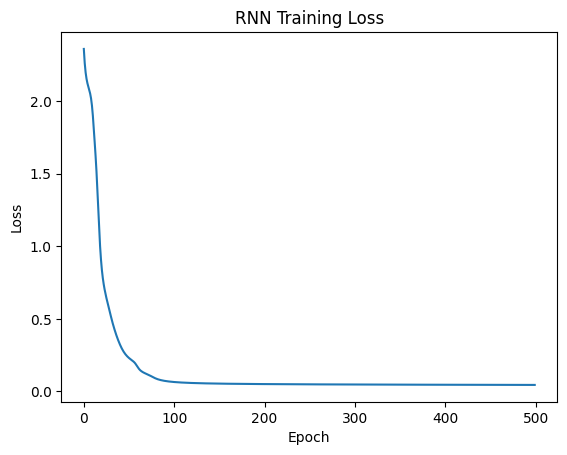

In [ ]:
# corpus
text = "the cat sat on the mat the cat ate the rat"
chars = sorted(set(text))
vocab_size = len(chars)
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}

print(f"Vocabulary: {chars}")
print(f"Vocab size: {vocab_size}")

# training
model = RNNFromScratch(input_size=vocab_size,
                        hidden_size=32,
                        output_size=vocab_size,
                        lr=0.05)

seq_length = 10
losses = []

for epoch in range(500):
    h = np.zeros(model.hidden_size)
    epoch_loss = 0
    n_batches = 0

    for i in range(0, len(text) - seq_length, seq_length):
        # preparing inputs and targets
        inputs = []
        targets = []

        for j in range(seq_length):
            x = np.zeros(vocab_size)
            x[char_to_idx[text[i+j]]] = 1
            inputs.append(x)
            targets.append(char_to_idx[text[i+j+1]])

        model.forward(inputs, h)
        loss = model.backward(inputs, targets)
        epoch_loss += loss
        n_batches += 1

    losses.append(epoch_loss / n_batches)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: loss={losses[-1]:.4f}")
        # sampling some text
        start = char_to_idx['t']
        sample_indices = model.sample(start, vocab_size, n_chars=40)
        sample_text = ''.join([idx_to_char[i] for i in sample_indices])
        print(f"Sample: {sample_text}")

# plotting loss curve
import matplotlib.pyplot as plt
plt.plot(losses)
plt.title('RNN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()